In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import warnings
# 忽略所有警告 (建議在開發完成、確認邏輯正確後再使用)
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt

# 解決中文顯示問題 (針對 Windows 系統)
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] # 設定字體為微軟正黑體
plt.rcParams['axes.unicode_minus'] = False              # 解決負號 '-' 顯示為亂碼的問題

In [22]:
import pandas as pd
import os

# 設定路徑
path = 'data/'

# 1. 讀取並直接設定
#  index
data1 = pd.read_csv(os.path.join(path, 'market_indices.csv'), encoding='utf-8-sig')
data1['日期'] = pd.to_datetime(data1['日期'])
data1.set_index('日期', inplace=True)

data2 = pd.read_csv(os.path.join(path, 'vix_index.csv'), encoding='utf-8-sig')
data2['日期'] = pd.to_datetime(data2['日期'])
data2.set_index('日期', inplace=True)

data3 = pd.read_csv(os.path.join(path, 'futures_chip.csv'), encoding='utf-8-sig')
data3['日期'] = pd.to_datetime(data3['日期'])
data3.set_index('日期', inplace=True)

data4 = pd.read_csv(os.path.join(path, 'margin_and_legal.csv'), encoding='utf-8-sig')
data4['日期'] = pd.to_datetime(data4['日期'])
data4.set_index('日期', inplace=True)

print("🎯 所有資料表的 Index 已轉換為『日期』。")
# 檢查其中一個表的結果


🎯 所有資料表的 Index 已轉換為『日期』。


In [24]:
data4

,外資買賣超,自營商買賣超,投信買賣超,電子外資買賣超,不含金電外資買賣超,金融外資買賣超,融資餘額,融資增減,券餘,借券賣出餘額
日期,,,,,,,,,,
2004-01-02,8499834,4900497,1129278,4999365,NaN,521663,272547417,-132112,841328,NaN
2004-01-05,5348486,3047683,2608299,3417406,NaN,-33907,274279482,1732065,898980,NaN
2004-01-06,8617334,1059223,453076,4494589,NaN,528053,274678946,399464,936913,NaN
2004-01-07,7338823,-6187,-181200,3824693,NaN,650908,275634321,955375,966783,NaN
2004-01-08,6365903,441064,-1391709,2831594,NaN,1598385,276615684,981363,974419,NaN
...,...,...,...,...,...,...,...,...,...,...
2026-03-16,-43825438,-3429648,324837,-39486303,2548482.0,-1733788,392284076,6837329,223950,15270802.0
2026-03-17,472382,9095274,205794,3720166,-1754601.0,-170765,393467032,1182956,215077,15430595.0
2026-03-18,9020754,9963133,-288069,8652699,-413548.0,-1043379,399772079,6305047,204948,15506401.0


In [25]:
#外資累計買賣超
fi = data4["外資買賣超"].cumsum()

In [26]:
#分產業外資累計買賣超
fi_3ind  = pd.DataFrame({
    "傳產外資買賣超": data4["不含金電外資買賣超"].cumsum(),
    "金融外資買賣超": data4["金融外資買賣超"].cumsum(),     
    "電子外資買賣超": data4["電子外資買賣超"].cumsum()
})


<Axes: xlabel='日期'>

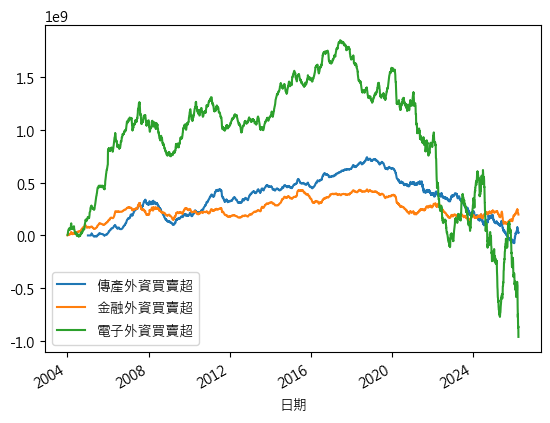

In [27]:
fi_3ind.plot()

In [52]:

#投信累計買賣超
i1= data4["投信買賣超"].cumsum()


#自營商累計買賣超
i2= data4["自營商買賣超"].cumsum()


In [ ]:
#上市櫃乖離差

In [37]:
def calculate_deviation(data, window=60):
    return (data - data.rolling(window=window).mean()) / data.rolling(window=window).mean() * 100
otc_deviation = calculate_deviation(data1["OTC指數:收盤價"])
market_deviation = calculate_deviation(data1["加權指數:收盤價"])

mo_deviation = market_deviation-otc_deviation


<Axes: xlabel='日期'>

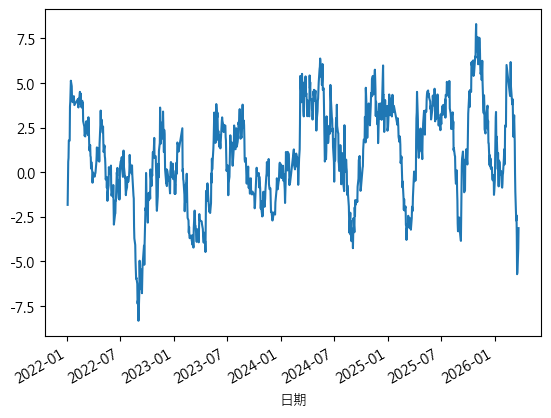

In [ ]:
mo_deviation.loc['2022':].plot()



In [49]:
#電金乖離差、電傳乖離差
tech_deviation = calculate_deviation(data1["電子類:收盤價"])
fin_devation = calculate_deviation(data1["金融保險:收盤價"])
tra_deviation = calculate_deviation(data1["不含金融電子:收盤價"])

#電金乖離差
tech_fin_deviation = tech_deviation - fin_devation
#電傳乖離差
tech_tra_deviation = tech_deviation - tra_deviation


In [ ]:
# 散戶淨部位

law = data3["MTX01自營商:多方未平倉"] + data3["MTX02投信:多方未平倉"] +data3["MTX03外資:多方未平倉"] - data3["MTX01自營商:空方未平倉"] - data3["MTX02投信:空方未平倉"] - data3["MTX03外資:空方未平倉"]    
mob = (-law).rolling(window=5).mean()

In [67]:
#外資淨部位
foreign_net =  data3["TX03外資:期貨多方未平倉"] - data3["TX03外資:期貨空方未平倉"]

In [68]:
#電子成交比重-市值比重

In [73]:
weight_diff = data1["電子類:成交值比重(%)"] - data1["電子類:市值比重(%)"]

In [ ]:
#oi


In [77]:
data3["TXOC台指選近月:全部未沖銷"]
data3["TXOC1台指選近月:全部未沖銷"]
data3["TXOP台指選近月:全部未沖銷"] 
data3["TXOP1台指選近月:全部未沖銷"]

日期
2004-01-02         NaN
2004-01-05         NaN
2004-01-06         NaN
2004-01-07         NaN
2004-01-08         NaN
                ...   
2026-03-16    153013.0
2026-03-17    177964.0
2026-03-18     57013.0
2026-03-19     90186.0
2026-03-20     63942.0
Name: TXOP1台指選近月:全部未沖銷, Length: 5464, dtype: float64

In [79]:
#pcr近月
pcr = data3["TXOP台指選近月:全部未沖銷"] / data3["TXOC台指選近月:全部未沖銷"]

In [ ]:
#所有月
put_oi = data3["TXOP1台指選近月:全部未沖銷"]

call_oi = data3["TXOC1台指選近月:全部未沖銷"]

In [92]:
#融資融券餘額
data4["券餘"]
data4["融資餘額"]

日期
2004-01-02    272547417
2004-01-05    274279482
2004-01-06    274678946
2004-01-07    275634321
2004-01-08    276615684
                ...    
2026-03-16    392284076
2026-03-17    393467032
2026-03-18    399772079
2026-03-19    402095986
2026-03-20    398591129
Name: 融資餘額, Length: 5464, dtype: int64